# Pipeline de análisis de fatiga muscular — Bíceps Braquial
## Equipo 4 | Biopotenciales Neuromusculares | Universidad Veracruzana

Este notebook corre el pipeline paso a paso para un sujeto. 
Útil para revisar la señal en cada etapa antes de correr el análisis completo.

**Protocolo:** curl de bíceps, 40 repeticiones, metrónomo 40 bpm, condiciones C0 (sin carga) y C5 (5 kg).

---


In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Agregar raíz del proyecto al path
sys.path.insert(0, os.path.abspath('..'))

from preprocessing.filter_butterworth import apply_filter, plot_filter_response
from analysis.mpf_calculator import load_signal, compute_mpf_all_blocks
from analysis.regression import fit_mpf_regression, summarize_results
from visualization.plot_mpf import (plot_raw_vs_filtered, plot_spectrum,
                                     plot_mpf_vs_block)

# Parámetros globales
FS       = 1000   # Frecuencia de muestreo (Hz)
N_BLOCKS = 5      # Número de bloques temporales
WINDOW   = 1000   # Tamaño de ventana FFT (muestras)
OVERLAP  = 500    # Traslape entre ventanas (muestras)
REST_S   = 10     # Segundos de reposo inicial
LOWCUT   = 20     # Corte inferior del filtro (Hz)
HIGHCUT  = 500    # Corte superior del filtro (Hz)

print("Módulos cargados correctamente.")
print(f"Parámetros: fs={FS} Hz | bloques={N_BLOCKS} | "
      f"ventana={WINDOW} muestras | filtro {LOWCUT}–{HIGHCUT} Hz")


Módulos cargados correctamente.
Parámetros: fs=1000 Hz | bloques=5 | ventana=1000 muestras | filtro 20–500 Hz


## Paso 1 — Carga de datos

Cambia las rutas según el sujeto que quieras analizar.  
Para probar con señal sintética dejalas igual.


In [2]:
# ── Rutas de los archivos ───────────────────────────────────────────────────
# Para datos reales: '../data/S01_C0.txt', '../data/S01_C5.txt'
# Para demo con señal sintética:
PATH_C0 = '../data/S05_C0.txt'
PATH_C5 = '../data/S05_C5.txt'
SUBJECT = 'S05'

# ── Carga ───────────────────────────────────────────────────────────────────
raw_c0, time_c0 = load_signal(PATH_C0, fs=FS)
raw_c5, time_c5 = load_signal(PATH_C5, fs=FS)

print(f"Sujeto: {SUBJECT}")
print(f"C0 — {len(raw_c0)} muestras  ({len(raw_c0)/FS:.1f} s)")
print(f"C5 — {len(raw_c5)} muestras  ({len(raw_c5)/FS:.1f} s)")


Sujeto: S05
C0 — 258735 muestras  (258.7 s)
C5 — 256405 muestras  (256.4 s)


## Paso 2 — Verificación del filtro

Antes de filtrar la señal, graficamos la respuesta en frecuencia del filtro
Butterworth para confirmar que el diseño es correcto.


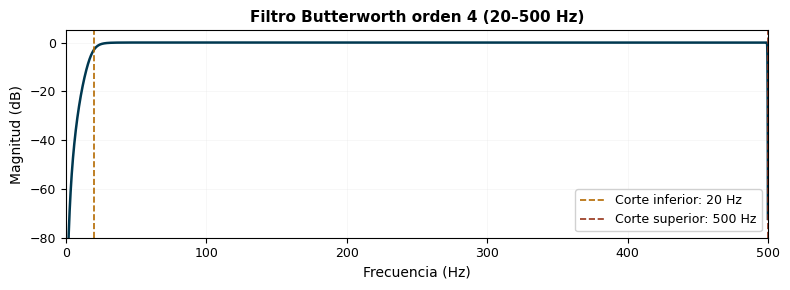

In [3]:
fig = plot_filter_response(fs=FS, lowcut=LOWCUT, highcut=HIGHCUT, order=4)
plt.show()


## Paso 3 — Filtrado de la señal

Aplicamos el filtro Butterworth pasa-banda (20–500 Hz) a las señales crudas.
El corte inferior en 20 Hz elimina los artefactos de movimiento generados
por el desplazamiento del cable durante el curl.


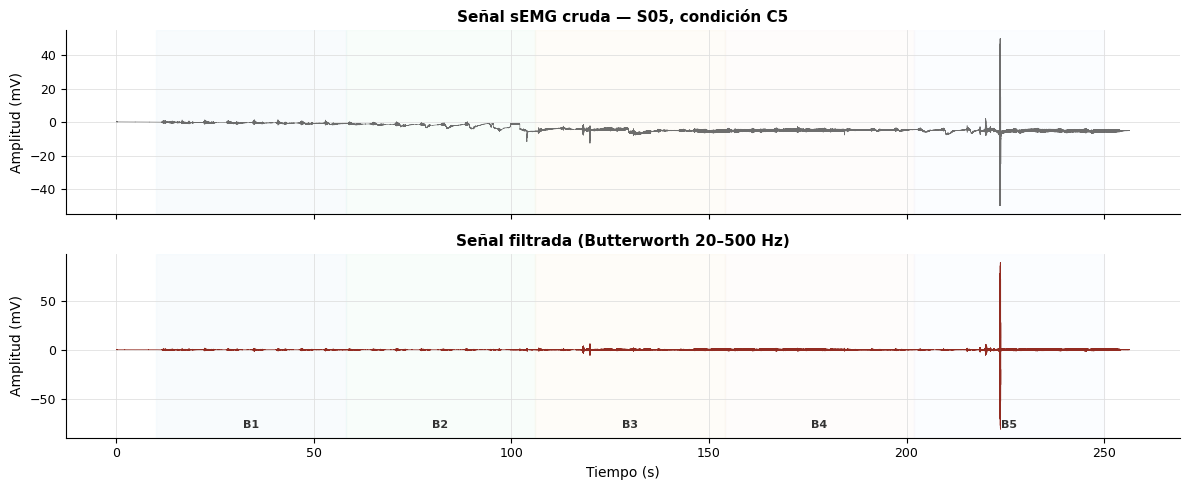

Filtrado completado.


In [4]:
filt_c0 = apply_filter(raw_c0, fs=FS, lowcut=LOWCUT, highcut=HIGHCUT)
filt_c5 = apply_filter(raw_c5, fs=FS, lowcut=LOWCUT, highcut=HIGHCUT)

# Señal cruda vs filtrada (condición C5 como ejemplo)
fig = plot_raw_vs_filtered(raw_c5, filt_c5, fs=FS,
                            subject=SUBJECT, condition='C5')
plt.show()
print("Filtrado completado.")


## Paso 4 — Espectro de potencia

Comparamos el espectro de la señal antes y después del filtrado para
confirmar que los artefactos de baja frecuencia fueron eliminados.


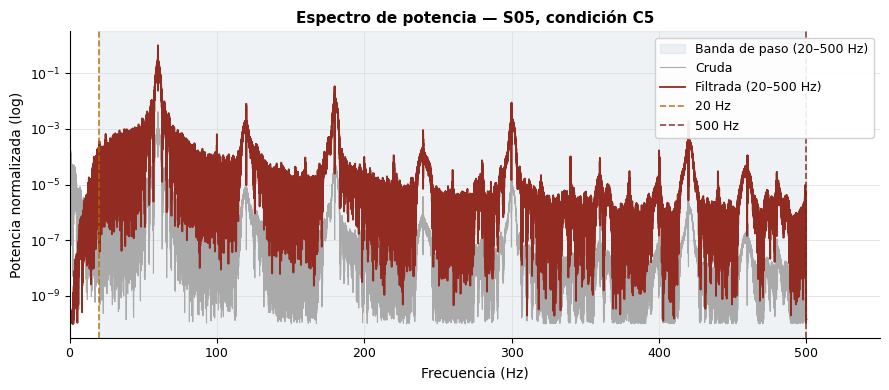

In [5]:
fig = plot_spectrum(raw_c5, filt_c5, fs=FS,
                    subject=SUBJECT, condition='C5')
plt.show()


## Paso 5 — Segmentación y cálculo de MPF

Dividimos la señal en 5 bloques de 8 repeticiones cada uno y calculamos
la Frecuencia Media de Potencia (MPF) de cada bloque usando FFT con
ventana deslizante de 1000 muestras y 50% de traslape.

$$\text{MPF} = \frac{\sum_f f \cdot \text{PSD}(f)}{\sum_f \text{PSD}(f)}$$

Un descenso progresivo de la MPF indica fatiga muscular acumulada.


In [6]:
mpf_c0, bloques_c0 = compute_mpf_all_blocks(
    filt_c0, fs=FS, n_blocks=N_BLOCKS,
    window=WINDOW, overlap=OVERLAP, rest_s=REST_S
)
mpf_c5, bloques_c5 = compute_mpf_all_blocks(
    filt_c5, fs=FS, n_blocks=N_BLOCKS,
    window=WINDOW, overlap=OVERLAP, rest_s=REST_S
)

print("MPF por bloque (Hz):")
print(f"  C0: {np.round(mpf_c0, 2)}")
print(f"  C5: {np.round(mpf_c5, 2)}")


MPF por bloque (Hz):
  C0: [116.86 123.45 119.27 121.35 142.47]
  C5: [71.5  74.83 72.68 75.06 82.55]


## Paso 6 — Regresión lineal

Ajustamos una recta a los 5 valores de MPF para obtener la pendiente
de fatiga (MPFs). Una pendiente más negativa en C5 que en C0 indica
que la carga de 5 kg acelera la fatiga del bíceps.

**Criterio de éxito:** R² > 0.5 y pendiente de C5 más negativa que C0.


In [7]:
res_c0 = fit_mpf_regression(mpf_c0)
res_c5 = fit_mpf_regression(mpf_c5)

summarize_results(SUBJECT, res_c0, res_c5)

print(f"\nCriterio R² > 0.5:")
print(f"  C0: R² = {res_c0['r2']:.3f}  →  {'OK' if res_c0['r2'] > 0.5 else 'No cumple'}")
print(f"  C5: R² = {res_c5['r2']:.3f}  →  {'OK' if res_c5['r2'] > 0.5 else 'No cumple'}")



--- Sujeto S05 ---
  C0 ->  MPFs = +4.912 Hz/bloque  |  R2 = 0.575  |  p = 0.137
  C5 ->  MPFs = +2.233 Hz/bloque  |  R2 = 0.673  |  p = 0.089
  Delta MPFs (C5 - C0) = -2.679 Hz/bloque
  -> C5 muestra mayor tasa de fatiga que C0 (esperado).

Criterio R² > 0.5:
  C0: R² = 0.575  →  OK
  C5: R² = 0.673  →  OK


## Paso 7 — Visualización: MPF vs. bloque

Gráfica principal del análisis: MPF vs. bloque para C0 y C5
con las rectas de regresión superpuestas.


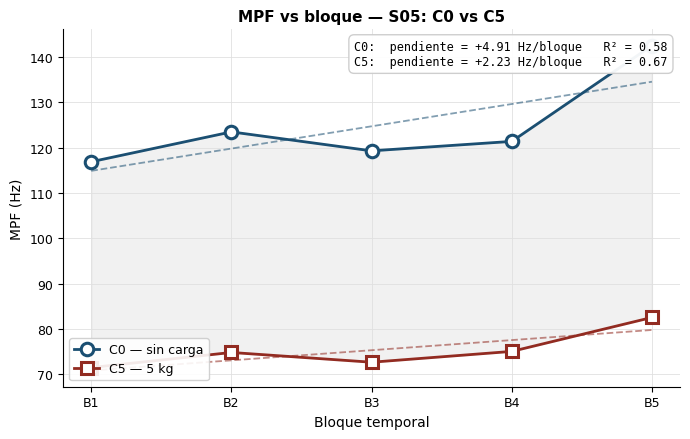

In [8]:
fig = plot_mpf_vs_block(mpf_c0, mpf_c5, res_c0, res_c5,
                         subject=SUBJECT)
plt.show()


## Paso 8 — Guardar figuras

Guarda todas las figuras en la carpeta `figuras/` para su visualizacion


In [9]:
os.makedirs('../figuras', exist_ok=True)

from preprocessing.filter_butterworth import apply_filter, plot_filter_response
from visualization.plot_mpf import (plot_raw_vs_filtered, plot_spectrum,
                                     plot_mpf_vs_block)

plot_raw_vs_filtered(raw_c5, filt_c5, fs=FS, subject=SUBJECT, condition='C5',
                      save_path=f'../figuras/fig1_senal_{SUBJECT}.png')
plt.close('all')

plot_spectrum(raw_c5, filt_c5, fs=FS, subject=SUBJECT, condition='C5',
              save_path=f'../figuras/fig2_espectro_{SUBJECT}.png')
plt.close('all')

plot_mpf_vs_block(mpf_c0, mpf_c5, res_c0, res_c5, subject=SUBJECT,
                   save_path=f'../figuras/fig3_mpf_{SUBJECT}.png')
plt.close('all')

print("Figuras guardadas en ../figuras/")


guardada: ../figuras/fig1_senal_S05.png
guardada: ../figuras/fig2_espectro_S05.png
guardada: ../figuras/fig3_mpf_S05.png
Figuras guardadas en ../figuras/


## Resumen de resultados

| Condición | Pendiente MPFs (Hz/bloque) | R² |
|-----------|--------------------------|-----|
| C0 — sin carga | — | — |
| C5 — 5 kg | — | — |

*(Reemplazar con los valores reales al correr con datos propios)*

**Interpretación:** Si la pendiente de C5 es más negativa que la de C0 y
el R² supera 0.5 en la mayoría de los sujetos, el sistema detecta
correctamente que la carga acelera la fatiga del bíceps braquial,
replicando la lógica de análisis de Fang et al. (2021).
